<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/24JulyMt_cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_csv('/content/drive/MyDrive/mtcars (1) - mtcars (1).csv')
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 2.9 KB


In [4]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [5]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


Determine the Features and Target variable

In [9]:
X = df.drop('mpg', axis=1)
y = df['mpg']

In [10]:
from sklearn.preprocessing import PolynomialFeatures

In [11]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [12]:
poly_features = polynomial_converter.fit(X)

In [13]:
poly_features = polynomial_converter.transform(X)

In [14]:
X.shape

(32, 10)

In [15]:
poly_features.shape

(32, 65)

In [16]:
# split the dataset for train and test
from sklearn.model_selection import train_test_split

In [17]:
X_train , X_test , y_train, y_test = train_test_split(X ,y ,test_size=0.3 , random_state=22)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train , y_train)

LinearRegression()

In [21]:
print("shape of original dataset :" ,df.shape )
print("shape of input - training set" , X_train.shape)
print("shape of output - training set" , y_train.shape)
print("shape of input - testing set" , X_test.shape)
print("shape of ouput - testing set" , y_test.shape)

shape of original dataset : (32, 11)
shape of input - training set (22, 10)
shape of output - training set (22,)
shape of input - testing set (10, 10)
shape of ouput - testing set (10,)


In [22]:
pd.DataFrame(model.coef_ , X.columns , columns=['Coefficient'])

,Coefficient
cyl,1.129370
disp,0.013644
hp,-0.016473
drat,3.039991
wt,-4.309623
qsec,0.790414
vs,-0.145564
am,-0.384248
gear,4.094838
carb,-1.136988


In [23]:
y_pred = model.predict(X_test)

In [24]:
pd.DataFrame({'Y_Test' : y_test , 'Y_Pred' : y_pred,'Residuals' : (y_test-y_pred)}).head()

,Y_Test,Y_Pred,Residuals
28,15.8,25.256303,-9.456303
29,19.7,20.069211,-0.369211
23,13.3,14.092442,-0.792442
10,17.8,20.363920,-2.563920
3,21.4,19.970520,1.429480


In [25]:
from sklearn import metrics
MAE_Poly = metrics.mean_absolute_error(y_test ,y_pred)
MSE_Poly = metrics.mean_squared_error(y_test, y_pred)
RMSE_Poly = np.sqrt(MSE_Poly)
pd.DataFrame([MAE_Poly , MSE_Poly , RMSE_Poly] , index = ['MAE' , 'MSE' , 'RMSE'] , columns=['metrics'])

,metrics
MAE,3.053053
MSE,17.187928
RMSE,4.145833


In [38]:
# train list of RMSE per degree
train_RMSE_list=[]
# test list of RMSE per degree
test_RMSE_list=[]
for d in range(1,10):
  # create poly data set for degree (d)
  polynomial_converter = PolynomialFeatures(degree=d , include_bias=False)
  poly_features = polynomial_converter.fit(X)
  poly_features = polynomial_converter.transform(X)
  # split the dataset
  X_train , X_test, y_train , y_test = train_test_split(poly_features , y, test_size=0.3,random_state=101)

  # train the model
  polymodel = LinearRegression()
  polymodel.fit(X_train , y_train)

  # predicting on both train & test data
  y_train_pred = polymodel.predict(X_train)
  y_test_pred = polymodel.predict(X_test)
  # evaluating the model
  # rmse of train set
  train_RMSE = np.sqrt(metrics.mean_squared_error(y_train ,y_train_pred))
  # rmse of test set
  test_RMSE = np.sqrt(metrics.mean_squared_error(y_test , y_test_pred))
  # append the rmse to the train and test split
  train_RMSE_list.append(train_RMSE)
  test_RMSE_list.append(test_RMSE)

In [39]:
train_RMSE_list

[np.float64(1.4953121903985143),
 np.float64(1.547195358371071e-12),
 np.float64(9.994168401489268e-13),
 np.float64(2.4101927593799566e-12),
 np.float64(7.865284206575869e-12),
 np.float64(7.078406621091966e-11),
 np.float64(3.055389977107997e-10),
 np.float64(8.715519473033853e-10),
 np.float64(6.186215333297066e-09)]

In [40]:
test_RMSE_list

[np.float64(4.332830783335178),
 np.float64(27.882587349090716),
 np.float64(19.830675101404424),
 np.float64(31.558832703797204),
 np.float64(54.05500382300317),
 np.float64(291.7592402936134),
 np.float64(1331.0523165609761),
 np.float64(5737.193986085641),
 np.float64(25939.679371454138)]

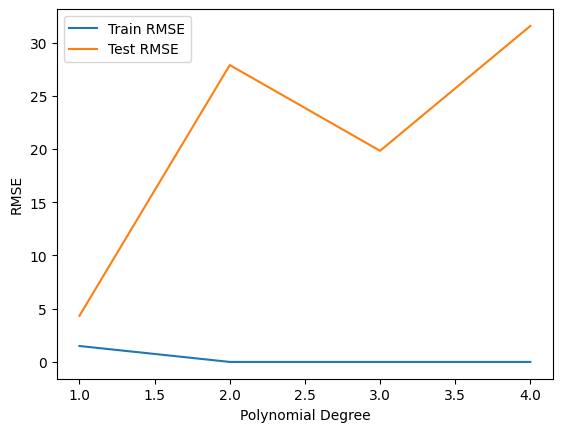

In [41]:
plt.plot(range(1,5) , train_RMSE_list[:4] , label='Train RMSE')
plt.plot(range(1,5) , test_RMSE_list[:4] , label ='Test RMSE')

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.legend()